In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed_data.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
print("Total Transactions:", len(df))

Total Transactions: 400916


In [5]:
print("Total Customers:", df["Customer ID"].nunique())

Total Customers: 4312


In [6]:
print("Unique Products:", df["StockCode"].nunique())

Unique Products: 4017


In [7]:
print("Countries:", df["Country"].nunique())

Countries: 37


In [8]:
print("Total Revenue: £{:,.2f}".format(df["TotalPrice"].sum()))

Total Revenue: £8,798,233.74


In [9]:
overview = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Unique Customers",
        "Unique Products",
        "Countries",
        "Total Revenue"
    ],
    "Value": [
        len(df),
        df["Customer ID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        round(df["TotalPrice"].sum(),2)
    ]
})

overview

,Metric,Value
0,Total Transactions,400916.00
1,Unique Customers,4312.00
2,Unique Products,4017.00
3,Countries,37.00
4,Total Revenue,8798233.74


In [10]:
country_sales = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64

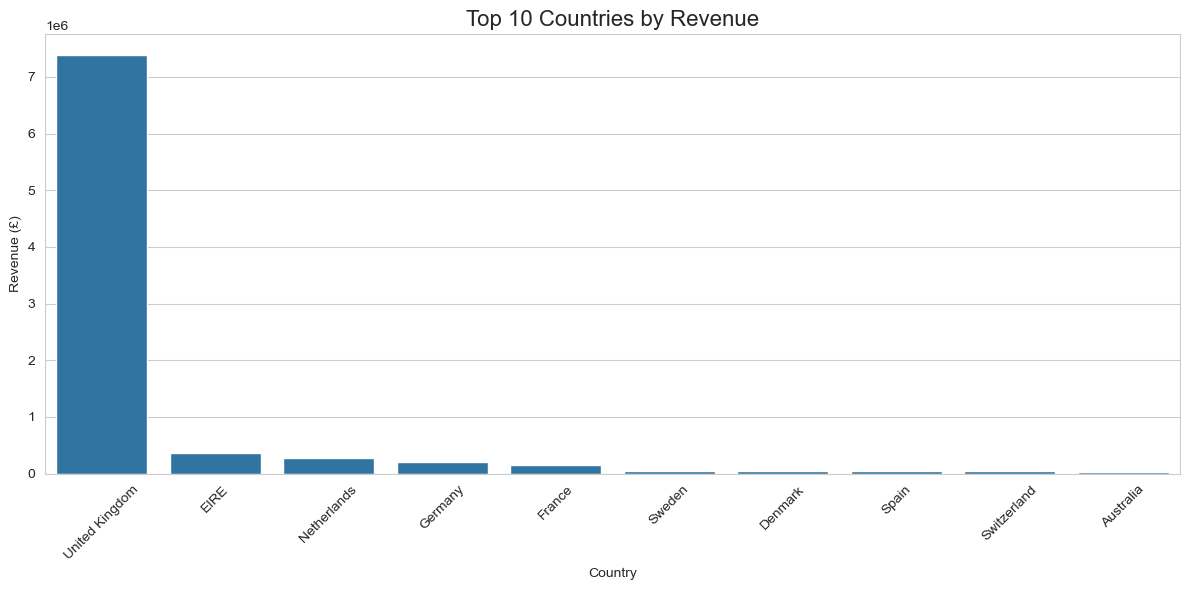

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.index,
    y=country_sales.values
)

plt.title("Top 10 Countries by Revenue", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The United Kingdom contributes the highest revenue by a very large margin compared to all other countries.

In [12]:
country_customers = (
    df.groupby("Country")["Customer ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

country_customers

Country
United Kingdom    3969
Germany             67
France              47
Spain               25
Netherlands         22
Portugal            18
Belgium             17
Sweden              16
Australia           15
Switzerland         14
Name: Customer ID, dtype: int64

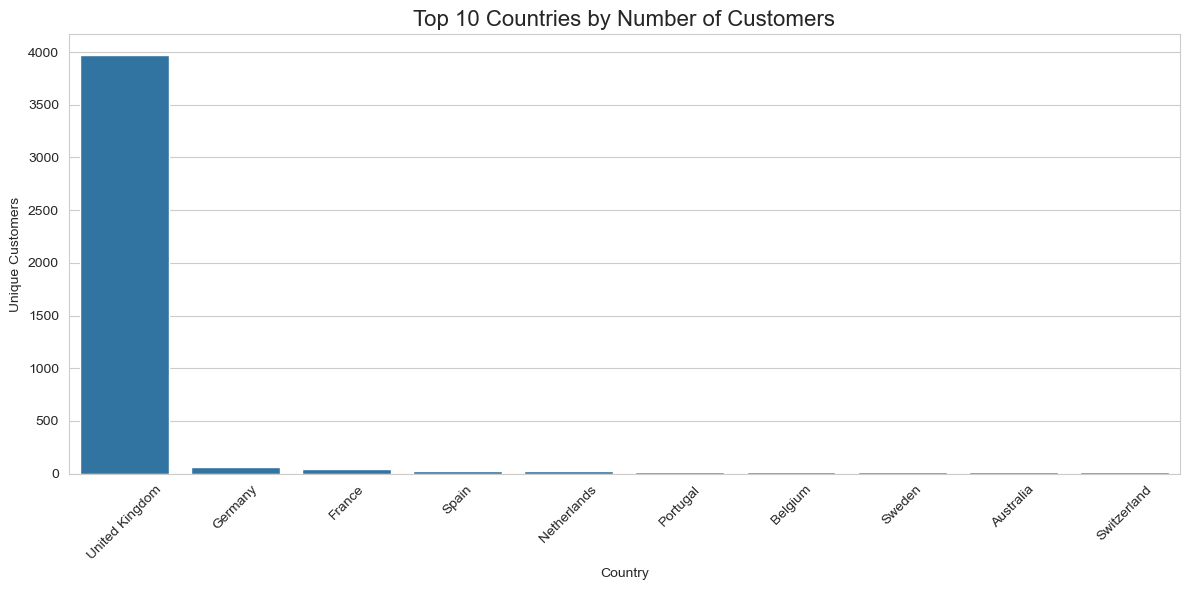

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_customers.index,
    y=country_customers.values
)

plt.title("Top 10 Countries by Number of Customers", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Unique Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
country_summary = (
    df.groupby("Country")
      .agg(
          Total_Revenue=("TotalPrice", "sum"),
          Customers=("Customer ID", "nunique")
      )
)

country_summary["Revenue_per_Customer"] = (
    country_summary["Total_Revenue"] / country_summary["Customers"]
)

country_summary.sort_values(
    by="Revenue_per_Customer",
    ascending=False
).head(10)

,Total_Revenue,Customers,Revenue_per_Customer
Country,,,
EIRE,356041.86,5,71208.372000
Netherlands,268784.35,22,12217.470455
Denmark,50906.85,9,5656.316667
Malta,5373.50,1,5373.500000
Lithuania,4892.68,1,4892.680000
Norway,23944.18,5,4788.836000
Singapore,4037.77,1,4037.770000
Greece,14335.67,4,3583.917500
Sweden,53147.99,16,3321.749375


In [15]:
df[df["Country"] == "EIRE"]["Customer ID"].nunique()

5

In [16]:
df[df["Country"] == "EIRE"]["Customer ID"].unique()

array([14911., 14156., 14016., 12745., 16047.])

In [17]:
Customers=("Customer ID","nunique")

In [18]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [19]:
monthly_sales = (
    df.groupby("YearMonth")["TotalPrice"]
      .sum()
)

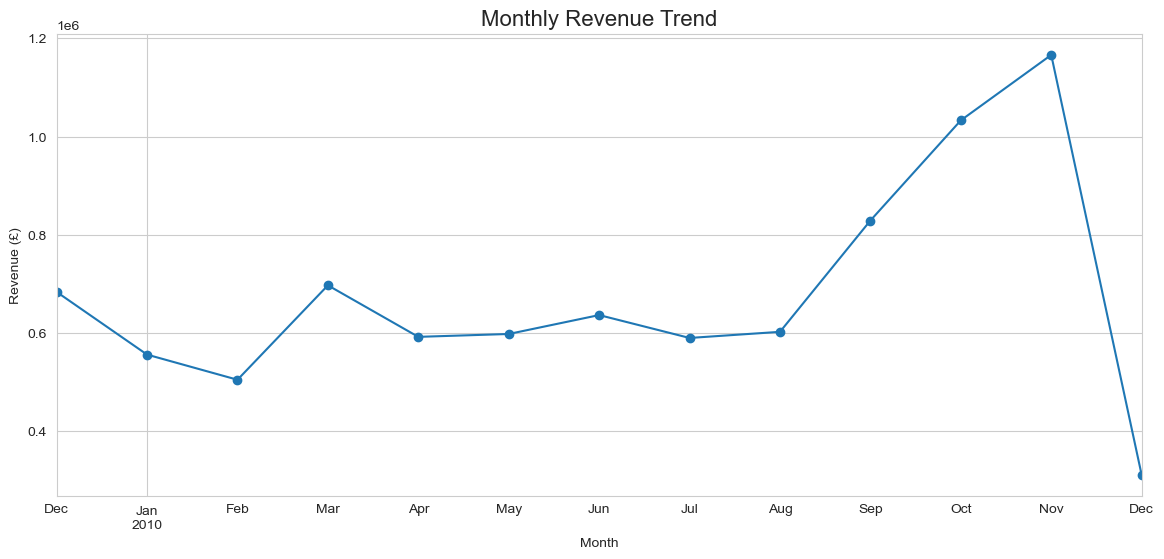

In [27]:
plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.grid(True)


plt.savefig("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")


plt.show()

In [21]:
df["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

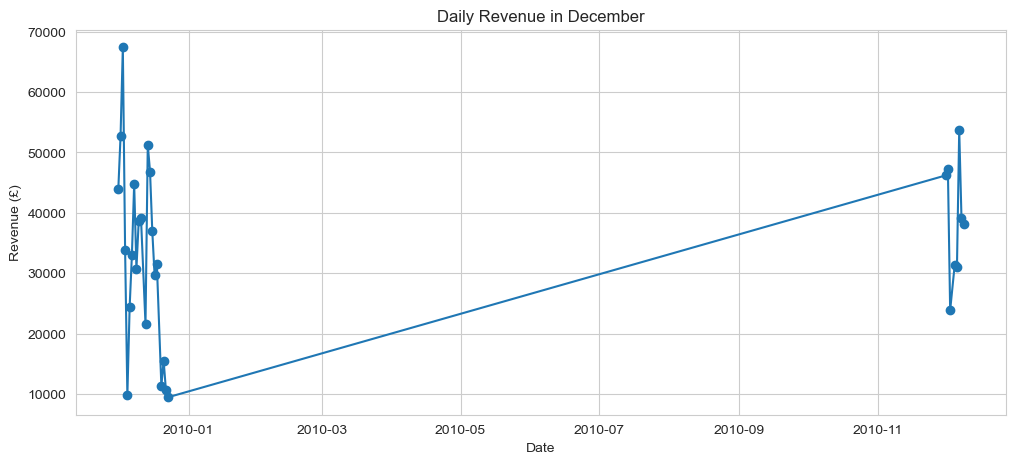

In [22]:
december = df[df["InvoiceDate"].dt.month == 12]

daily_sales = (
    december.groupby(december["InvoiceDate"].dt.date)["TotalPrice"]
            .sum()
)

plt.figure(figsize=(12,5))
daily_sales.plot(marker="o")

plt.title("Daily Revenue in December")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")

plt.show()

In [23]:
df["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

In [24]:
top_customers = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: TotalPrice, dtype: float64

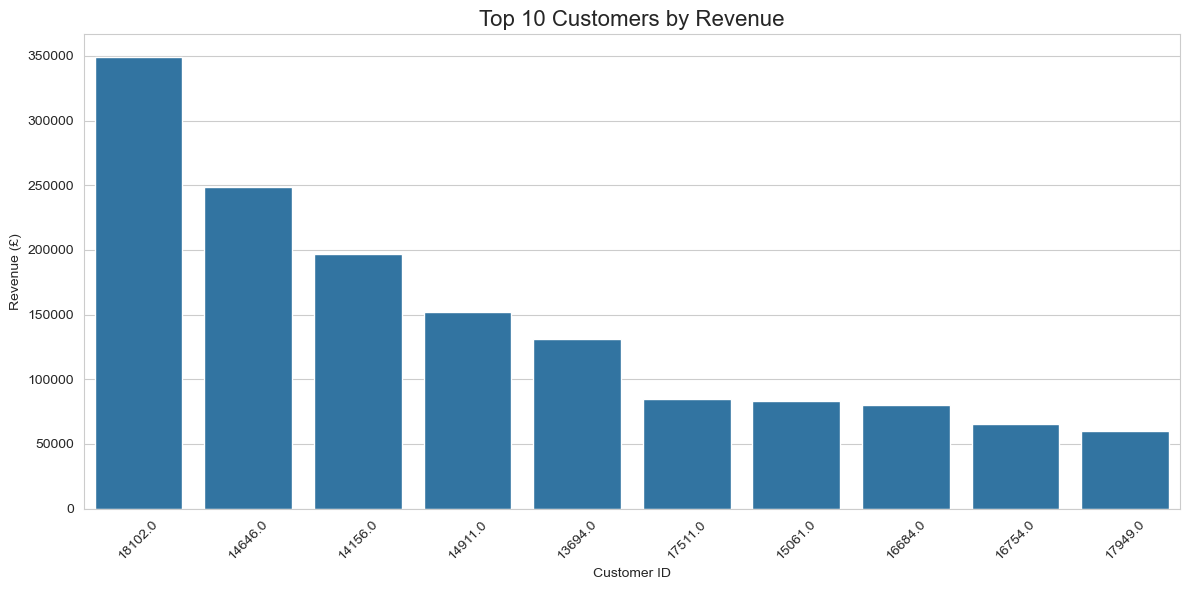

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers.values
)

plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()